# Aprendizaje Estadístico y Data Mining

## Práctica 3: Bosques incendiados

### Objetivo
El SEPRONA quiere saber qué cómo afectan distintas características meteorológicas a la cantidad de bosquequemado en un incendio. Para ello tiene información sobre casos anteriores. La información se encuentra en el archivo **“incendios.csv”** y está compuesta por distintas características de las cuales interesa saber la influencia de la temperatura, humedad, viento y lluvia.

Basándonos en el enunciado, podemos determinar que nos encontramos ante un problema de **regresión**, ya que se pide estudiar como unas ciertas variables (características meteorológicas) afectan al area de un incendio (variable objetivo).

Instalar librerias:

In [19]:
#%pip install pandas scikit-learn numpy matplotlib scipy ipympl

Importar librerías necesarias:

In [20]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from scipy.stats import pearsonr
from scipy import stats
import seaborn as sns

**Enunciado:** Crea al menos dos modelos con dos de las variables a estudiar. Haz una interpretación de ambos y di como cambian.  

**Solución**

#### Carga y preprocesamiento del dataset
En primer lugar, comenzaremos cargando el dataset que contiene la información necesaria. Una vez cargado, para evitar que los datos estén demasiado sesgados, aplicaremos una transformación logaritmica (*log-transformación*) en el campo del area, ya que en este tipo de incendios, pueden ser pequeños, lo que tendría un valor entre 0 y 1, o muy grandes, que puede irse a más de 100. Para evitar eso, le aplicamos un logaritmo a este atributo, de tal manera que obtenemos una distribución más simétrica, mucho menos sesgada, y conseguimos relaciones lineales. 

In [21]:
df = pd.read_csv("data/incendios.csv")

df = df.drop(columns=['month', 'day']) # Eliminamos las columnas que no vamos a utilizar

df['area'] = df['area'].replace(0, 0.1) # Cambiamos los 0 por 0.1 para evitar hacer log(0)

df['log_area'] = np.log(df['area'])

Antes de empezar a crear los modelos, estudiaremos la correlación de las diferentes variables con el área.

In [22]:
correlations = {}
for column in df.columns:
    if column != 'area' and column != 'log_area':
        corr, _ = pearsonr(df[column], df['area'])
        correlations[column] = corr

print("---- CORRELACIONES ----")
for feature, corr_value in correlations.items():
    print(f"Correlación {feature} - area: {corr_value:.4f}")

---- CORRELACIONES ----
Correlación X - area: 0.0633
Correlación Y - area: 0.0448
Correlación FFMC - area: 0.0401
Correlación DMC - area: 0.0730
Correlación DC - area: 0.0493
Correlación ISI - area: 0.0082
Correlación temp - area: 0.0978
Correlación RH - area: -0.0755
Correlación wind - area: 0.0123
Correlación rain - area: -0.0074


#### Creación de modelos
Ya con el dataset cargado y preprocesado, podemos proceder con la creación de los modelos de regresión.  

**- Modelo 1:** Para este primer modelo, utilizaremos las variables *temp* y *RH* (Temperatura con humedad relativa en el aire).

In [23]:
X1 = df[['temp', 'RH']]
y = df['log_area']

X_train, X_test, y_train, y_test = train_test_split(X1, y, test_size=0.2, random_state=42)

model1 = LinearRegression()
model1.fit(X_train, y_train)


print("---- COEFICIENTES ----")
print("Coeficientes (temp, RH):", model1.coef_)
print("Intercepto:", model1.intercept_)
print("R2 score en test:", model1.score(X_test, y_test))

---- COEFICIENTES ----
Coeficientes (temp, RH): [0.01633019 0.00037388]
Intercepto: -0.46604610573650845
R2 score en test: 0.006633124764173437


Viendo estos resultados podemos sacar las siguientes conclusiones:
- **Coeficientes**
  - **Coeficiente *temp*** (0.0163): Con este valor, podríamos decir que por cada unidad de temperatura que aumenta, el area del **incendio también aumenta *0.0163 unidades***, es decir, que tiene una relación de directa ligera con respecto al area.  
  
  - **Coeficiente *RH*** (0.0037): En este caso podemos ver que el efecto de la humedad relativa en la extensión del área quemada es muy baja. En este modelo no parece de manera significativa.  

- **Intercepto** (-0.446)
- **R2** (0.0066): El score R2 del modelo es muy bajo, por lo que no predice mucho mejor que la media. Esto puede deberse o bien a la falta de datos de entrenamiento, o bien porque la relación entre las variables con respecto al área sea débil.

**- Modelo 2:** Para este primer modelo, utilizaremos las variables *wind* y *rain*.

In [24]:
X2 = df[['wind', 'rain']]

X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y, test_size=0.2, random_state=42)

model2 = LinearRegression()
model2.fit(X_train2, y_train2)

print("---- COEFICIENTES ----")
print("Coeficientes (wind, rain):", model2.coef_)
print("Intercepto:", model2.intercept_)
print("R2 score en test:", model2.score(X_test2, y_test2))

---- COEFICIENTES ----
Coeficientes (wind, rain): [0.0499293  0.23366332]
Intercepto: -0.345620838081466
R2 score en test: 0.010951565828036691


Las conclusiones que podemos sacar de este segundo modelo son prácticamente iguales que las del primero. Podríamos destacar el coeficiente de la lluvia, ya que el valor que da podría parecer contradictorio, ya que lo más lógico sería que cuanto más llueva, menos probabilidades de incendio. Aún así, podría ocurrir que la humedad del suelo y del ambiente, puedas favorecer de alguna manera la propagación del fuego en caso de un indencio forestal.

**Enunciado:** Realiza otros dos modelos con tres variables. Haz una interpretación de ellos. Selecciona el que creas más útil. Dibújalo si es posible teniendo en cuenta las variables más influyentes.

**Solución**

#### Creación de modelos con 3 variables

In [25]:
# -------- Modelo 3 --------
features_3 = ['temp', 'wind', 'RH']
X_3 = df[features_3]
X_3_train, X_3_test, y_train, y_test = train_test_split(X_3, y, test_size=0.2, random_state=42)
model_3 = LinearRegression().fit(X_3_train, y_train)
y_pred_3 = model_3.predict(X_3_test)
r2_A = r2_score(y_test, y_pred_3)

print("Modelo 3 (temp, wind, RH):")
print("  Coeficientes:", model_3.coef_)
print("  Intercepto:", model_3.intercept_)
print("  R2:", r2_A)

# -------- Modelo 4 --------
features_4 = ['FFMC', 'DMC', 'ISI']
X_4 = df[features_4]
X_4_train, X_4_test, y_train, y_test = train_test_split(X_4, y, test_size=0.2, random_state=42)
model_B = LinearRegression().fit(X_4_train, y_train)
y_pred_B = model_B.predict(X_4_test)
r2_B = r2_score(y_test, y_pred_B)

print("\nModelo 4 (FFMC, DMC, ISI):")
print("  Coeficientes:", model_B.coef_)
print("  Intercepto:", model_B.intercept_)
print("  R2:", r2_B)

Modelo 3 (temp, wind, RH):
  Coeficientes: [0.02118987 0.06670236 0.00055676]
  Intercepto: -0.8325950501391874
  R2: 0.024412028348051784

Modelo 4 (FFMC, DMC, ISI):
  Coeficientes: [ 0.03275399  0.00297543 -0.04700595]
  Intercepto: -3.0276781692917196
  R2: -0.02083105944591801


En este caso, hemos decidido crear dos modelos con enfoques distintos:
- **Modelo 3:** Para este, utilizamos la temperatura, el viento y la humedad relativa, partiendo de la hipótesis de que cuanta más temperatura y viento hiciese, y menos humedad existiese, se se darían condiciones más favorables a la extensión de un incendio. Tras el entrenamiento del modelo, pudimos realizar el siguiente análisis:
    - ***Coeficientes:*** El factor que más aporta en este caso es el viento (0.066), seguido de la temperatura (0.021), mientras que la humédad relativa queda en un plano más insignificante (0.0005).
    - ***R2 (0.02):*** Al igual que en los modelos de dos variables, el resultado predictivo sigue siendo muy bajo, aunque sigue prediciendo algo mejor que la media de los atributos. Aún así, es de los mejores que pudimos sacar tras hacer varias combinaciones de atributos.  

- **Modelo 4:** Para el segundo modelo, elegimos las variables relativas a la sequedad de la vegetación fina, la humedad del suelo vegetal, y la rapidez inicial de propagación del hiciendo. Con estas variables, supusimos que cuanta mayor sequedad (y por lo tanto, menos humedad), sumado a la rapida propagación inicial del incendio, más probabilidades habrían para la expansión del fuego. Tras el entrenamiento, realizamos el siguiente analisis:
    -***Coeficientes:*** Comenzando con el FFMC, podemos corroborar que cuanto mayor sequedad, mayor área del incendio. Con el DMC, podemos comprobar que hay un impacto mucho menor, cosa que también se adapta a nuestra hipótesis inicial. Lo raro es el valor del ISI, ya que el coeficiente es negativo (-0.047), ya que teniendo en cuenta que mide la velocidad de propagación del fuego, es raro que indique menor área de expansión.
    -***R2 (-0.02):*** En este caso, el módelo precide peor que la media de los datos, por lo que no es un modelo que podamos elegir para nuestra predicción.  


Teniendo todo esto en cuenta, nos quedaremos con el modelo 3.

#### Grafica del Modelo 3

c:\Users\Carmen\anaconda3\envs\Data_Mining\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


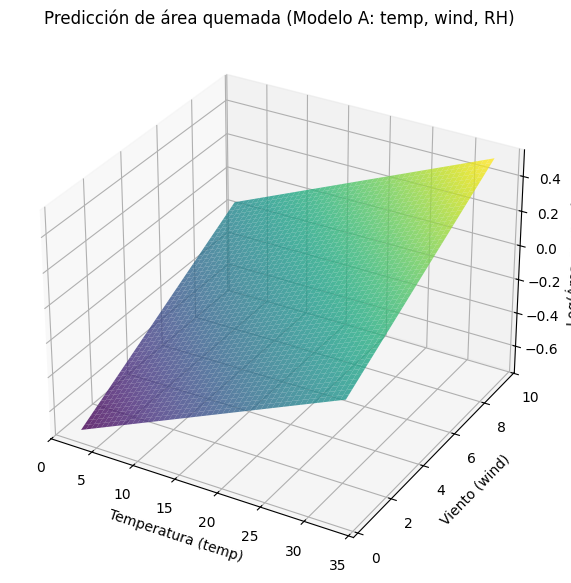

In [26]:
temp_range = np.linspace(df['temp'].min(), df['temp'].max(), 50)
wind_range = np.linspace(df['wind'].min(), df['wind'].max(), 50)

temp_grid, wind_grid = np.meshgrid(temp_range, wind_range)

RH_mean = df['RH'].mean()

X_grid = np.column_stack((temp_grid.ravel(), wind_grid.ravel(), np.full(temp_grid.size, RH_mean)))

y_grid_pred = model_3.predict(X_grid)
y_grid_pred = y_grid_pred.reshape(temp_grid.shape)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(temp_grid, wind_grid, y_grid_pred, cmap='viridis', alpha=0.8)
ax.set_xlabel('Temperatura (temp)')
ax.set_ylabel('Viento (wind)')
ax.set_zlabel('Log(Área quemada)')
ax.set_title('Predicción de área quemada (Modelo A: temp, wind, RH)')

plt.show()

Para graficar el modelo, hemos utilizado una representación en 3D, utilizando *temperatura* y *viento* como variables predictivas, y dejando *RH* fija (cogiendo la media), ya que es la que menos impacto tenía. Como podemos observar, cuanto más viento y temperatura hay, mayor area quemada produce el incendio.

**Enunciado:** Haz un análisis de residuos del modelo lo más exhaustivo posible.

**Solución**

#### Análisis de residuos del Modelo 3

En primer lugar, calcularemos los residuos de nuestro modelo siguiendo la siguiente fórmula:  
$$Residuos=Valor Observado−Valor Predicho$$

In [27]:
y_pred = model_3.predict(X_3_test)
residuos = y_test - y_pred

Con los residuos calculados, procederemos a realizar distintas gráficas para ver si el modelo está sesgado o encontrar algún otro indicativo de su mal funcionamiento.

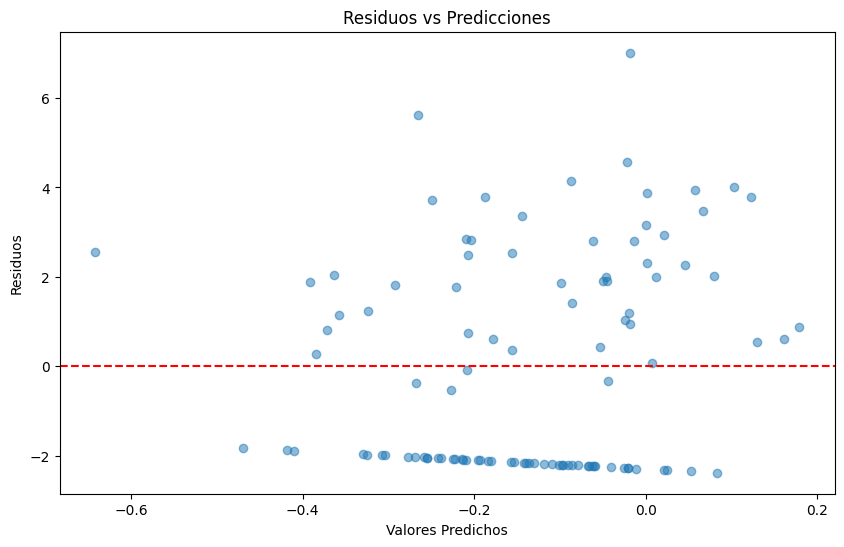

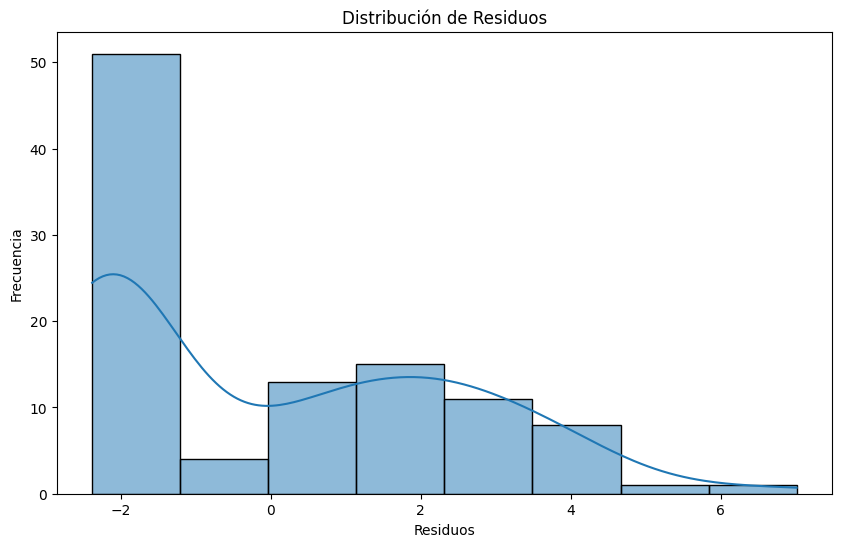

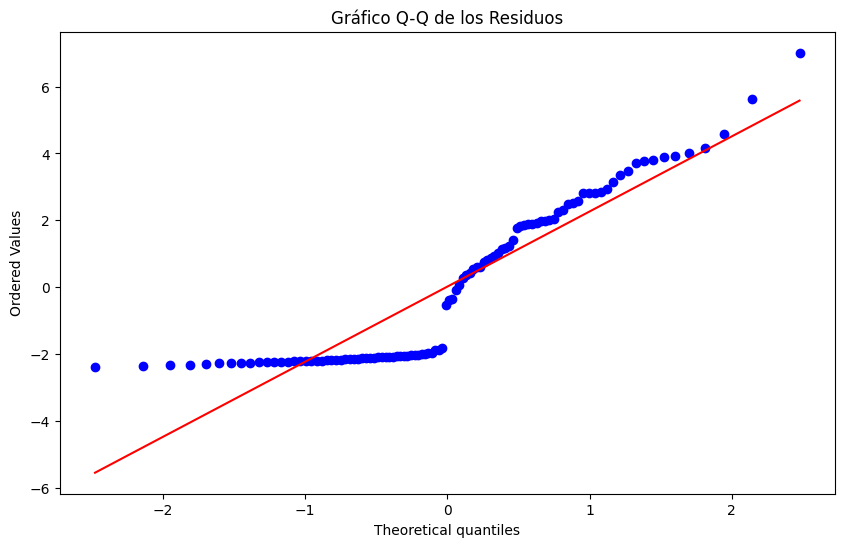

In [28]:
# 1. Gráfico de residuos vs. valores predichos
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuos, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuos vs Predicciones')
plt.xlabel('Valores Predichos')
plt.ylabel('Residuos')
plt.show()

# 2. Histograma de residuos
plt.figure(figsize=(10, 6))
sns.histplot(residuos, kde=True)
plt.title('Distribución de Residuos')
plt.xlabel('Residuos')
plt.ylabel('Frecuencia')
plt.show()

# 3. Gráfico QQ de los residuos
plt.figure(figsize=(10, 6))
stats.probplot(residuos, dist="norm", plot=plt)
plt.title('Gráfico Q-Q de los Residuos')
plt.show()

En los tres gráficos, podemos ver que hay datos anómales en el rango de -2 a 0, más concretamente en el -2 (por la información que nos da el histograma). Este nos puede indicar un sesgo o asímetria en la distribución de los residuos, por lo que no sigue una distribución normal correctamente.  

Por esta razón, es posible que el modelo tenga esos resultados tan bajos, ya que está o bien haciendo predicciones sesgadas, o bien la relación entre las variables no es del todo lineal.

**Enunciado:** Utiliza los intervalos de confianza para obtener la mayor información posible con ellos. 

**Solución**

#### Calculo de intervalos de confianza


In [29]:
mse = np.mean(residuos ** 2)

# Calcula los errores estándar para los coeficientes
X_3_con_intercepto = np.c_[np.ones(X_3_train.shape[0]), X_3_train]  # Añade la columna para el intercepto
XTX_inv = np.linalg.inv(np.dot(X_3_con_intercepto.T, X_3_con_intercepto))  # Inversa de X^T * X
errores_estandar = np.sqrt(np.diagonal(mse * XTX_inv))

# Grados de libertad
n, p = X_3_train.shape
df = n - p - 1

# Calcula el valor crítico t para un intervalo de confianza del 95%
alpha = 0.05  # 95% de confianza
valor_t = stats.t.ppf(1 - alpha / 2, df)

# Calcula los intervalos de confianza para cada coeficiente
coeficientes = model_3.coef_
intercepto = model_3.intercept_

# Muestra los intervalos de confianza
print("\nIntervalos de confianza para los coeficientes:")
for i, feature in enumerate(features_3):
    # Usamos errores_estandar[i+1] porque errores_estandar[0] corresponde al intercepto
    limite_inferior = coeficientes[i] - valor_t * errores_estandar[i+1]
    limite_superior = coeficientes[i] + valor_t * errores_estandar[i+1]
    print(f"{feature}: {coeficientes[i]:.4f} [{limite_inferior:.4f}, {limite_superior:.4f}]")

# Muestra el intervalo de confianza para el intercepto
print(f"\nIntercepto: {intercepto:.4f} [{intercepto - valor_t * errores_estandar[0]:.4f}, {intercepto + valor_t * errores_estandar[0]:.4f}]")


Intervalos de confianza para los coeficientes:
temp: 0.0212 [-0.0276, 0.0700]
wind: 0.0667 [-0.0666, 0.2000]
RH: 0.0006 [-0.0161, 0.0172]

Intercepto: -0.8326 [-2.4733, 0.8081]
